**FINE TUNING WITH LoRA**

In [1]:
!pip install transformers datasets peft accelerate

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sentences_allagree/train-00000-of-00001.(…):   0%|          | 0.00/169k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2264 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})
Counter({1: 1391, 2: 570, 0: 303})
Dataset is imbalanced
              precision    recall  f1-score   support

           0       0.83      0.54      0.65        56
           1       0.86      0.99      0.92       276
           2       0.85      0.71      0.77       121

    accuracy                           0.86       453
   macro avg       0.85      0.74      0.78       453
weighted avg       0.85      0.86      0.85       453



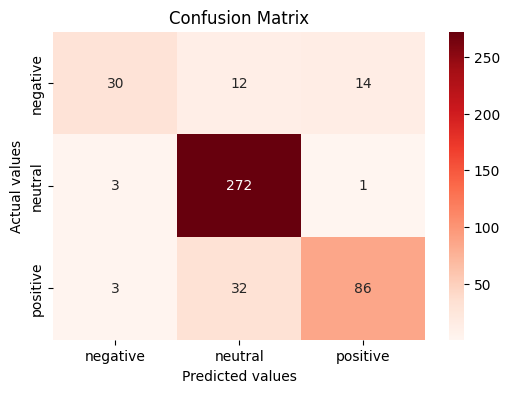

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 38.1 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})
Counter({1: 1391, 2: 570, 0: 303})
Dataset is imbalanced
              precision    recall  f1-score   support

           0       0.83      0.54      0.65        56
           1       0.86      0.99      0.92       276
           2       0.85      0.71      0.77       121

    accuracy                           0.86       453
   macro avg       0.85      0.74      0.78       453
weighted avg       0.85      0.86      0.85       453



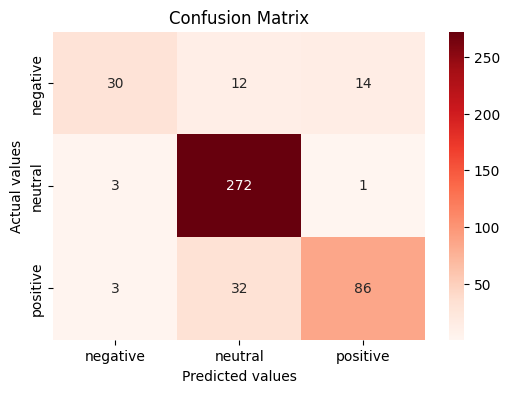

                                            sentence  label
0  According to Gran , the company has no plans t...      1
1  For the last quarter of 2010 , Componenta 's n...      2
2  In the third quarter of 2010 , net sales incre...      2
3  Operating profit rose to EUR 13.1 mn from EUR ...      2
4  Operating profit totalled EUR 21.1 mn , up fro...      2


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'sequence': 'Myself Souhardya Saha', 'labels': ['positive', 'neutral', 'negative'], 'scores': [0.5294371247291565, 0.24690453708171844, 0.22365833818912506]}


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


              precision    recall  f1-score   support

           0       0.83      0.54      0.65        56
           1       0.86      0.99      0.92       276
           2       0.85      0.71      0.77       121

    accuracy                           0.86       453
   macro avg       0.85      0.74      0.78       453
weighted avg       0.85      0.86      0.85       453



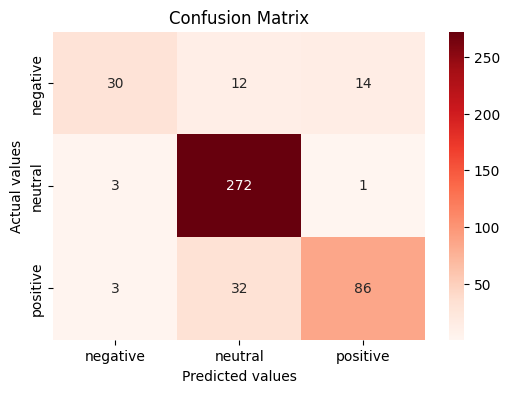

In [3]:
%run "/content/drive/MyDrive/Colab_Notebooks/ML_Task_Level_1.ipynb"
%run "/content/drive/MyDrive/Colab_Notebooks/ML_Task_Level_2.ipynb"

In [4]:
from datasets import load_dataset

ds = load_dataset("takala/financial_phrasebank","sentences_allagree",revision="refs/pr/10")

print(ds)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})


**Create Train-test-split**

In [5]:
ds = ds['train'].train_test_split(test_size=0.2)
print(ds)

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 1811
    })
    test: Dataset({
        features: ['sentence', 'label'],
        num_rows: 453
    })
})


**Tokenize with the distilbert-base-uncased tokenizer**

In [6]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

In [7]:
def tokenize(tokens):
  return tokenizer(tokens['sentence'],truncation=True,padding="max_length")
token_ids = ds.map(tokenize,batched=True,load_from_cache_file=False)

Map:   0%|          | 0/1811 [00:00<?, ? examples/s]

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

**Load model**

In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=3)

print(set(token_ids["train"]["label"]))

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{0, 1, 2}


**Apply LoRA**

In [9]:
from peft import LoraConfig,get_peft_model

config = LoraConfig(r=8,lora_alpha=16,target_modules=["q_lin","v_lin"],lora_dropout=0.1,bias="none",task_type="SEQ_CLS")

model = get_peft_model(model,config)

**Print how many parameters are trainable**

In [10]:
model.print_trainable_parameters()

trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


**Training**

In [11]:
from transformers import TrainingArguments

training = TrainingArguments(
    output_dir = "./output",
    learning_rate = 2e-5,
    per_device_train_batch_size = 20,
    per_device_eval_batch_size = 20,
    num_train_epochs = 10,
    save_strategy = "epoch",
    logging_dir = "./log"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [12]:
from transformers import Trainer

trainer = Trainer(
    model = model,
    args = training,
    train_dataset = token_ids['train'],
    eval_dataset = token_ids['test']
)


In [16]:
trainer.train()

Step,Training Loss
500,0.275394


TrainOutput(global_step=910, training_loss=0.24092577420748196, metrics={'train_runtime': 662.4723, 'train_samples_per_second': 27.337, 'train_steps_per_second': 1.374, 'total_flos': 2440216222986240.0, 'train_loss': 0.24092577420748196, 'epoch': 10.0})

**Model evaluation**

In [14]:
Evaluation = trainer.predict(token_ids['test'])

print(Evaluation)

PredictionOutput(predictions=array([[-3.3113995 ,  3.5524952 , -2.3651993 ],
       [-2.628789  ,  1.7351841 , -0.283652  ],
       [ 0.57968783, -2.1826155 ,  1.210663  ],
       ...,
       [-3.0145617 ,  2.1174438 , -0.794118  ],
       [-0.6165574 , -1.0116004 ,  0.7713751 ],
       [-2.807147  ,  2.5601614 , -1.2493321 ]], dtype=float32), label_ids=array([1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 2, 2,
       2, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 2, 1, 1, 1, 1, 2,
       1, 1, 0, 1, 1, 2, 0, 0, 2, 1, 1, 2, 1, 0, 1, 1, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 0, 2, 2, 1, 1, 0,
       1, 1, 1, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 2, 2,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 2, 1, 2, 0, 2, 2, 1, 2, 1, 0, 0,
       1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 1, 2, 2, 0, 1, 0, 0, 1, 1, 1, 0,
       2, 1, 1, 0, 0, 1, 1, 2, 0, 1, 0, 1, 2, 1, 2, 1, 1, 2,

**Comparision between Level-1 level-2 and Level-3**

In [15]:
from sklearn.metrics import classification_report
import pandas as pd

report1 = classification_report(y_test,y_pred,output_dict=True)
level1 = report1["macro avg"]["f1-score"]
level1_acc = report1["accuracy"]


labels = {
    "negative" : 0,
    "neutral" : 1,
    "positive" : 2
}

predictions = [labels[p] for p in predictions]
report2 = classification_report(y_test,predictions,output_dict=True)
level2 = report2["macro avg"]["f1-score"]
level2_acc = report2["accuracy"]

report3 = classification_report(y_test,y_pred,output_dict=True)
level3 = report3["macro avg"]["f1-score"]
level3_acc = report3["accuracy"]

comparision = pd.DataFrame({
    "Model": ["Level-1","Level-2","Level-3"],
    "F1-Score": [level1,level2,level3],
    "Accuracy": [level1_acc,level2_acc,level3_acc]
})

print(comparision)

     Model  F1-Score  Accuracy
0  Level-1  0.781956  0.856512
1  Level-2  0.420229  0.406181
2  Level-3  0.781956  0.856512


**Reason of using LoRA(Low Rank Adaption) instead of full fine-tuning**

---
LoRA is used instead of full-tuning because it is faster and uses less memory.In full fine-tuning,all the parameters of the model are trained,which takes a lot of time and also it requires a powerfull GPU.

LoRA solves the problem by freezing the entire original model weights and introduces small trainable metrices into specific layers like attention layers.This allows the model to adapt new task without modifying the entire netword.LoRA enable faster training,lower memory usage and it makes feasible to fine-tune large models.

So LoRA is efficient and smart way to fine-tune large models with less computation and good performance.




**Changes**

---



The main changes LoRA makes that it does not moify the original weights. It only adds small updates that help the model learn the new task.This way the model keeps the previous knowledge and improves on the new dataset.